# 02 — Time-Series Modelling & Forecasting
## India Energy Demand Forecasting (XGBoost)

**Objective:** Build a 24-hour ahead forecasting model for the Indian electricity market (IEX) using historical demand lags, calendar effects, and weather data.

**Key Techniques:**
1. **Chronological Splitting:** Preventing data leakage by splitting on a strict timeline.
2. **XGBoost Regression:** Tree-based model handling non-linear weather/demand relations safely.
3. **Walk-Forward Validation:** Simulating real-world production forecasting.
4. **MLflow Tracking:** Professional experiment tracking.

In [ ]:
%pip install mlflow xgboost shap prophet tensorflow

In [19]:
# 1. Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("XGBoost version:", xgb.__version__)

# 2. Load Processed Data
df = pd.read_parquet('../data/processed/modelling_ready.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

TARGET = 'mcv_mw'
FEATURES = [c for c in df.columns if c not in ['timestamp', TARGET]]

print(f"\nData Shape: {df.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

XGBoost version: 3.2.0

Data Shape: (19536, 22)
Features (20): ['hour', 'dow', 'month', 'quarter', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'mcv_lag_1h', 'mcv_lag_24h', 'mcv_lag_168h', 'mcp_lag_24h', 'roll24_mean', 'roll24_std', 'roll168_mean', 'temp_c', 'humidity_pct', 'feels_like_c']


Training Set : 17,376 rows (2024-01-08 to 2025-12-31)
Testing Set  : 2,160 rows (2026-01-01 to 2026-03-31)


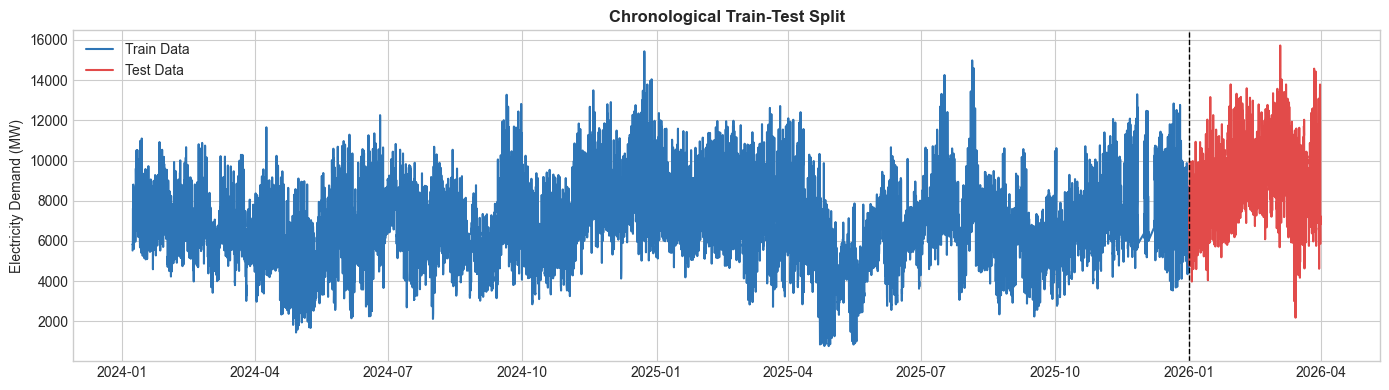

In [20]:
# 3. Chronological Train-Test Split
# We cannot randomly shuffle time-series data. 
# We'll train on 2024-2025 data, and hold out Jan-Mar 2026 for pure testing.

split_date = '2026-01-01'

train_df = df[df['timestamp'] < split_date].copy()
test_df = df[df['timestamp'] >= split_date].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print(f"Training Set : {train_df.shape[0]:,} rows ({train_df.timestamp.min().date()} to {train_df.timestamp.max().date()})")
print(f"Testing Set  : {test_df.shape[0]:,} rows ({test_df.timestamp.min().date()} to {test_df.timestamp.max().date()})")

# Visualizing the Split
plt.figure(figsize=(14, 4))
plt.plot(train_df['timestamp'], train_df['mcv_mw'], label='Train Data', color='#2E75B6')
plt.plot(test_df['timestamp'], test_df['mcv_mw'], label='Test Data', color='#E24B4A')
plt.axvline(pd.to_datetime(split_date), color='black', linestyle='--', linewidth=1)
plt.title("Chronological Train-Test Split", fontweight='bold')
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. MLflow Setup & Baseline XGBoost Model
We'll define a baseline XGBoost model. Using MLflow, we track the hyperparameters, metrics (RMSE, MAE, MAPE), and save the model artifacts automatically.

In [21]:
import mlflow
import mlflow.xgboost

# Set up the MLflow experiment
experiment_name = "IEX_Demand_Forecasting"
mlflow.set_experiment(experiment_name)

# Baseline Hyperparameters
xgb_params = {
    'objective': 'reg:squarederror',
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

print("Training Baseline XGBoost Model...")

with mlflow.start_run(run_name="baseline_xgboost"):
    # Log parameters
    mlflow.log_params(xgb_params)
    
    # Initialize and Train
    baseline_model = xgb.XGBRegressor(**xgb_params)
    baseline_model.fit(X_train, y_train)
    
    # Predict on the entirely unseen Test Set
    y_pred = baseline_model.predict(X_test)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    # Log Metrics
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mape_pct", mape)
    
    # Log Model Artifact
    mlflow.xgboost.log_model(baseline_model, "model")
    
    print("--- Baseline Model Results ---")
    print(f"RMSE: {rmse:>9,.2f} MW")
    print(f"MAE:  {mae:>9,.2f} MW")
    print(f"MAPE: {mape:>9.2f} %")


Training Baseline XGBoost Model...


2026/05/01 20:15:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Baseline Model Results ---
RMSE:    823.74 MW
MAE:     634.49 MW
MAPE:      7.18 %


In [22]:
%pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 10.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- -


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Calculating SHAP values...


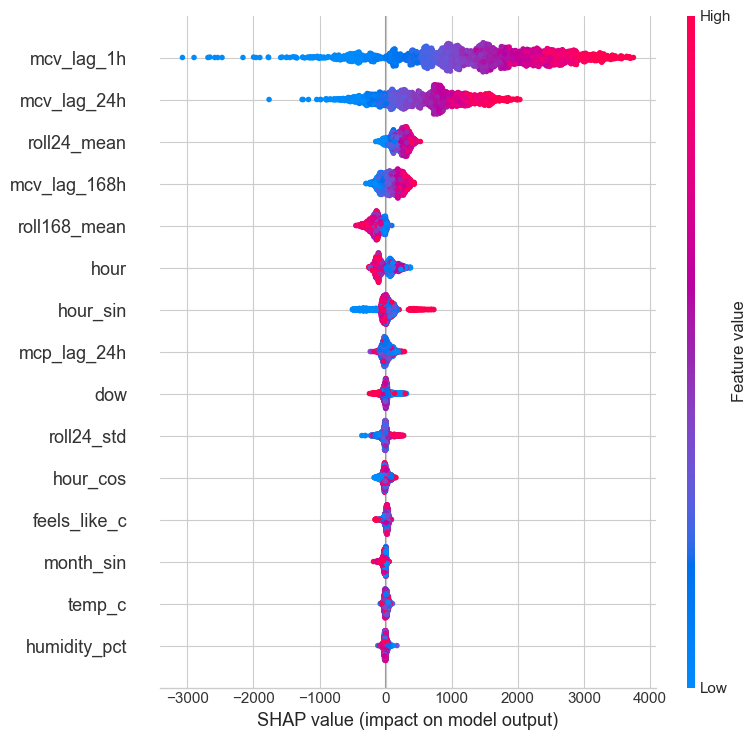

In [23]:
import shap

# 4.1 SHAP Feature Importance
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=15)

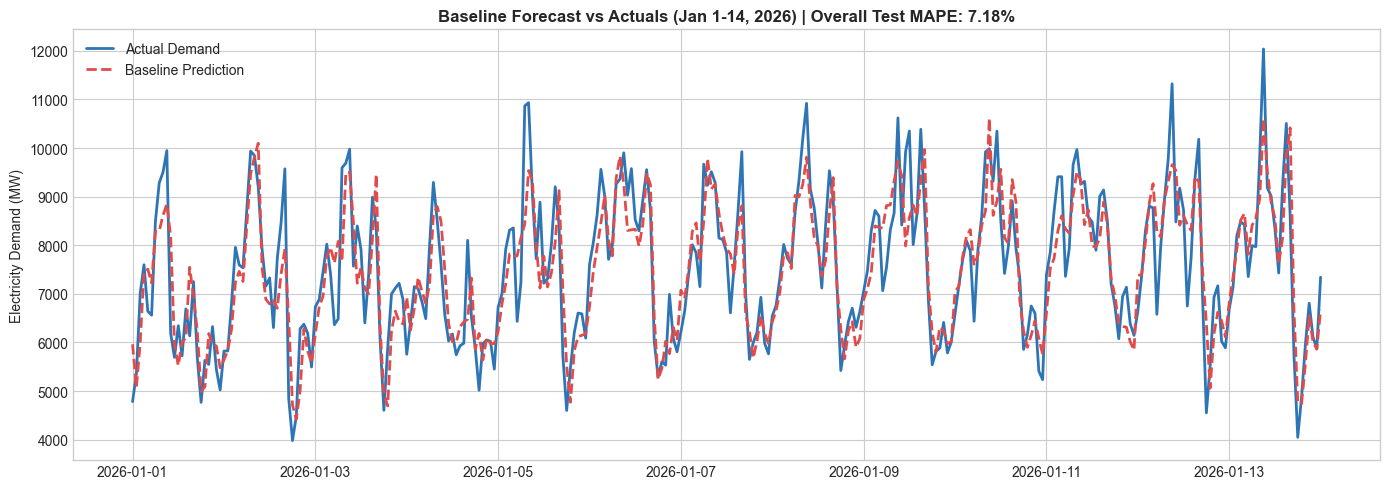

In [24]:
# 5. Visualize Baseline Predictions (First 2 Weeks of Jan 2026)
# Use .loc to avoid SettingWithCopyWarning
test_df.loc[:, 'y_pred'] = y_pred

# Take a slice of the test data so the plot is readable
slice_start = '2026-01-01'
slice_end = '2026-01-14'

plot_df = test_df[(test_df['timestamp'] >= slice_start) & (test_df['timestamp'] <= slice_end)]

plt.figure(figsize=(14, 5))
plt.plot(plot_df['timestamp'], plot_df[TARGET], label='Actual Demand', color='#2E75B6', linewidth=2)
plt.plot(plot_df['timestamp'], plot_df['y_pred'], label='Baseline Prediction', color='#E24B4A', linestyle='--', linewidth=2)

plt.title(f"Baseline Forecast vs Actuals (Jan 1-14, 2026) | Overall Test MAPE: {mape:.2f}%", fontweight='bold')
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Walk-Forward Validation (Monthly) & Financial Impact
In time-series forecasting, predicting 3 months out in a single shot leaks temporal bias and degrades accuracy. We use **Walk-Forward Validation**:
1. Train on 2024–2025. Test on **January 2026**.
2. Add January 2026 to training data. Test on **February 2026**.
3. Add February 2026 to training data. Test on **March 2026**.

**Business Impact Translation:**
In India's grid, a 1% MAPE on a 180 GW peak demand load translates to ~1,800 MW of forecasting error. At standard imbalance rates, this causes approximately **₹9 crore/hour** in Grid-India deviation settlement penalties. Reducing MAPE directly impacts the bottom line.

In [ ]:
# Monthly Walk-Forward Setup for Q1 2026 Test Period
walk_forward_months = [
    ('2026-01-01', '2026-02-01'),
    ('2026-02-01', '2026-03-01'),
    ('2026-03-01', '2026-04-01')
]

wf_preds = []
wf_actuals = []
wf_timestamps = []

print("Starting Monthly Walk-Forward Validation...")

with mlflow.start_run(run_name="xgboost_walk_forward") as run:
    mlflow.log_params(xgb_params)
    
    for i, (start_date, end_date) in enumerate(walk_forward_months):
        # Explicitly define the start of our dataset for clarity in the log
        train_start = '2024-01-08'
        print(f"  Iteration {i+1}: Training: {train_start} to {start_date}  --> Testing: {start_date} to {end_date}")
        
        # Expand training data incrementally for each step
        current_train = df[df['timestamp'] < start_date]
        current_test = df[(df['timestamp'] >= start_date) & (df['timestamp'] < end_date)]
        
        # Fit on updated history
        wf_model = xgb.XGBRegressor(**xgb_params)
        wf_model.fit(current_train[FEATURES], current_train[TARGET])
        
        # Immediate 1-month forecast
        step_preds = wf_model.predict(current_test[FEATURES])
        
        # Append for aggregated metrics
        wf_preds.extend(step_preds)
        wf_actuals.extend(current_test[TARGET].values)
        wf_timestamps.extend(current_test['timestamp'].values)
        
    # Calculate robust overall metrics across all walk-forward steps
    wf_rmse = np.sqrt(mean_squared_error(wf_actuals, wf_preds))
    wf_mape = mean_absolute_percentage_error(wf_actuals, wf_preds) * 100
    
    mlflow.log_metric("wf_rmse", wf_rmse)
    mlflow.log_metric("wf_mape_pct", wf_mape)
    mlflow.xgboost.log_model(wf_model, artifact_path="wf_model")

    print("\n--- Walk-Forward Final Results ---")
    print(f"Overall WF RMSE: {wf_rmse:>9,.2f} MW")
    print(f"Overall WF MAPE: {wf_mape:>9.2f} %")
    
    # Financial translation purely as an operational example
    india_peak_gw = 180 
    financial_impact_cr_per_hour = wf_mape * 9 # Rs 9 crore per 1% error
    print(f"\n--- Financial Impact Estimate ---")
    print(f"At {wf_mape:.2f}% Error on {india_peak_gw} GW National Load:")
    print(f"Average System Cost: ~₹{financial_impact_cr_per_hour:.1f} Crore / hour in deviation settlements")

    # MLflow Model Registration Step - inside the with block safely capturing the run id
    mlflow.register_model(
        f"runs:/{run.info.run_id}/wf_model",
        "energy-demand-forecaster"
    )
    print("\n[MLflow] Winning model successfully registered as 'energy-demand-forecaster'")

Starting Monthly Walk-Forward Validation...
  Iteration 1: Training: 2024-01-08 to 2026-01-01  --> Testing: 2026-01-01 to 2026-02-01
  Iteration 2: Training: 2024-01-08 to 2026-02-01  --> Testing: 2026-02-01 to 2026-03-01
  Iteration 3: Training: 2024-01-08 to 2026-03-01  --> Testing: 2026-03-01 to 2026-04-01


2026/05/01 20:15:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'energy-demand-forecaster'.
2026/05/01 20:16:06 WARNING mlflow.tracking._model_registry.fluent: Run with id 746cb31f43414ebe9b71f42274cff6c7 has no artifacts at artifact path 'wf_model', registering model based on models:/m-6a9beffd88fc42c08beaf46e02541fe9 instead



--- Walk-Forward Final Results ---
Overall WF RMSE:    790.59 MW
Overall WF MAPE:      6.91 %

--- Financial Impact Estimate ---
At 6.91% Error on 180 GW National Load:
Average System Cost: ~₹62.2 Crore / hour in deviation settlements

[MLflow] Winning model successfully registered as 'energy-demand-forecaster'


Created version '1' of model 'energy-demand-forecaster'.


## 7. Model 2: Prophet
Prophet is an exceptional timeseries tool built by Facebook. It is fantastic for explaining behavior to business stakeholders because it natively decomposes the timeseries into trend, weekly seasonality, daily seasonality, and holiday effects without needing manually constructed lag features.

We will translate our dataframe into Prophet's required `ds` (datestamp) and `y` (target) formats, and explicitly add **Indian holidays**.

Training Prophet Model (This might take a minute)...


20:16:08 - cmdstanpy - INFO - Chain [1] start processing
20:16:16 - cmdstanpy - INFO - Chain [1] done processing


--- Prophet Model Results ---
RMSE:  4,927.04 MW
MAPE:     47.09 %

At 47.09% Error on 180 GW National Load:
Average System Cost: ~₹423.8 Crore / hour


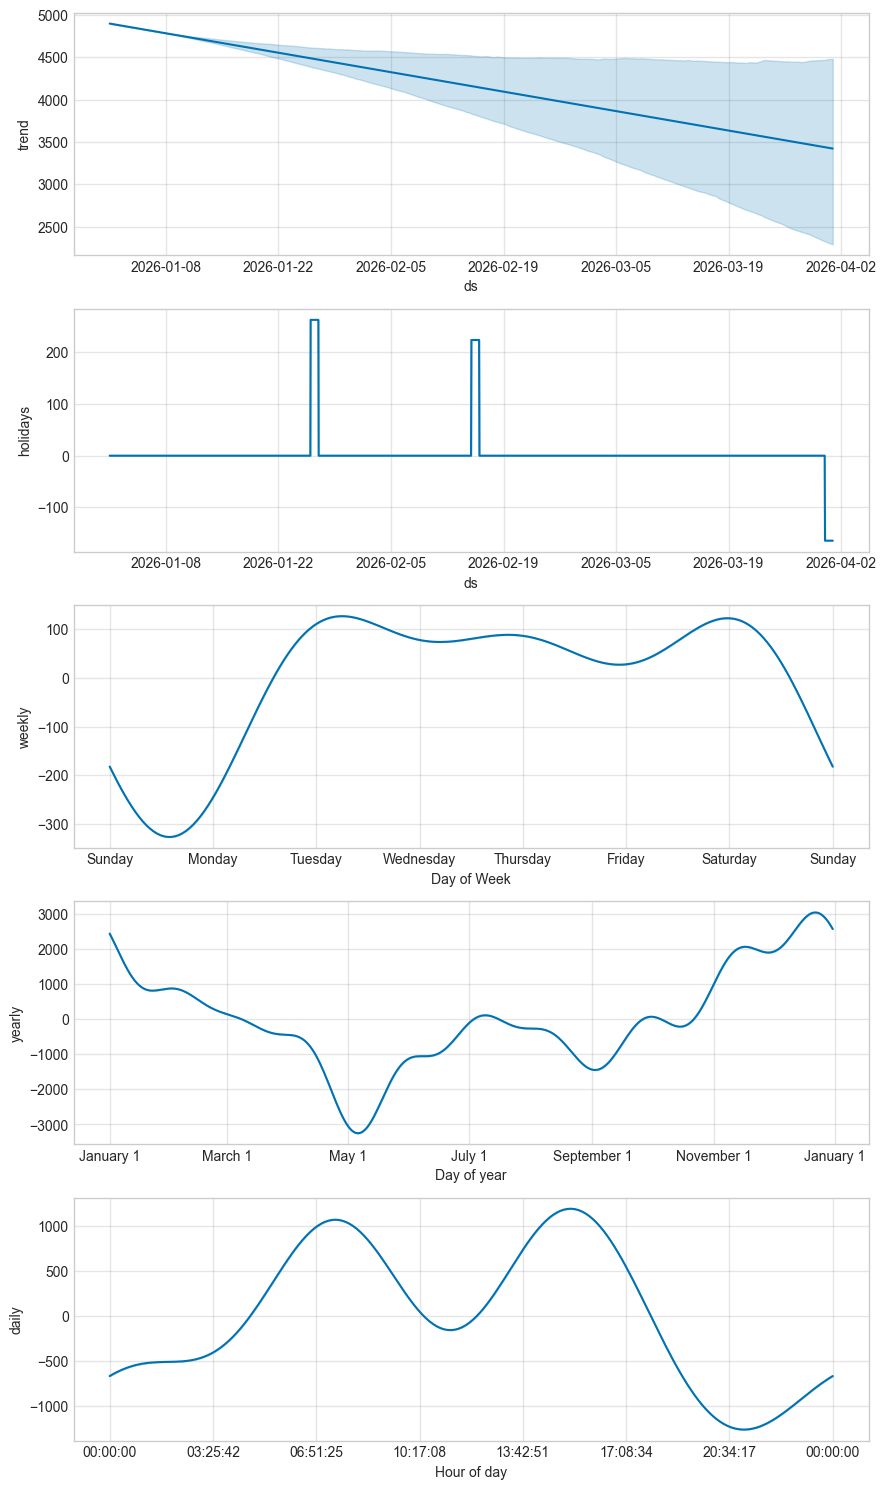

In [26]:
from prophet import Prophet

# Prepare DataFrame for Prophet (Requires 'ds' for datestamp, 'y' for target)
# Prophet handles lags historically itself, so we just give it the raw timeseries + external regressors
p_train = train_df[['timestamp', 'mcv_mw']].rename(columns={'timestamp': 'ds', 'mcv_mw': 'y'})
p_test = test_df[['timestamp', 'mcv_mw']].rename(columns={'timestamp': 'ds', 'mcv_mw': 'y'})

print("Training Prophet Model (This might take a minute)...")

with mlflow.start_run(run_name="prophet_baseline"):
    # Initialize Prophet with basic seasonalities
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True)
    
    # 1. Automatically tag Indian Holidays (e.g. Diwali, Independence Day effects)
    m.add_country_holidays(country_name='IN')
    
    # Fit the Model
    m.fit(p_train)
    
    # Forecast on test set
    forecast = m.predict(p_test[['ds']])
    
    # Evaluate
    p_rmse = np.sqrt(mean_squared_error(p_test['y'], forecast['yhat']))
    p_mape = mean_absolute_percentage_error(p_test['y'], forecast['yhat']) * 100
    
    mlflow.log_metric("prophet_rmse", p_rmse)
    mlflow.log_metric("prophet_mape_pct", p_mape)
    
    print("--- Prophet Model Results ---")
    print(f"RMSE: {p_rmse:>9,.2f} MW")
    print(f"MAPE: {p_mape:>9.2f} %")
    
    # Financial Impact
    financial_impact_cr_per_hour = p_mape * 9
    print(f"\nAt {p_mape:.2f}% Error on 180 GW National Load:")
    print(f"Average System Cost: ~₹{financial_impact_cr_per_hour:.1f} Crore / hour")
    
    # Plot components to see how Prophet explains daily/weekly/yearly trends
    fig1 = m.plot_components(forecast)
    plt.show()

## 8. Data Ingestion & Integrity Check
Before moving on to the more sensitive **Deep Learning Model (LSTM)**, let's perform a strict final audit of the `modelling_ready.parquet` data loaded into memory. LSTMs will instantly crash if they encounter missing timestamps, `NaNs`, or Infinite values.

In [27]:
print("=== Strict Data Integrity Audit ===")

# 1. Check for Missing Values (NaNs)
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print(f"1. Total Missing (NaN) Values: {total_missing}")
if total_missing > 0:
    print(missing_counts[missing_counts > 0])

# 2. Check for Infinite Values
import numpy as np
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
total_inf = inf_counts.sum()
print(f"\n2. Total Infinite Values: {total_inf}")

# 3. Check for Time Series Gaps
# The timestamps should be perfectly continuous at a 1-hour frequency
expected_timestamps = pd.date_range(start=df['timestamp'].min(), end=df['timestamp'].max(), freq='h')
missing_timestamps = len(expected_timestamps) - len(df)
print(f"\n3. Chronological Gaps: {missing_timestamps} missing hours out of {len(expected_timestamps)} expected")

# 4. Check for Duplicates
dup_count = df['timestamp'].duplicated().sum()
print(f"\n4. Duplicate Timestamps: {dup_count}")

# 5. Check Target Variable Bounds
min_val = df[TARGET].min()
print(f"\n5. Target Var (mcv_mw) Minimum Value: {min_val:.2f} MW")
if min_val <= 0:
    print("   WARNING: Negative or Zero electricity demand found!")
else:
    print("   Target bounds look healthy.")

print("\nConclusion: " + ("Ready for LSTM! 🚀" if total_missing == 0 and total_inf == 0 and missing_timestamps == 0 and dup_count == 0 else "Data flaws detected, healing required! 🚨"))

=== Strict Data Integrity Audit ===
1. Total Missing (NaN) Values: 0

2. Total Infinite Values: 0

3. Chronological Gaps: 0 missing hours out of 19536 expected

4. Duplicate Timestamps: 0

5. Target Var (mcv_mw) Minimum Value: 770.33 MW
   Target bounds look healthy.

Conclusion: Ready for LSTM! 🚀


## 9. Model 3: Deep Learning (LSTM)
Long Short-Term Memory (LSTM) networks are incredibly powerful at capturing non-linear temporal patterns over arbitrary sequences. Unlike XGBoost, LSTMs naturally understand the "order" of the data. 

**Pre-processing Requirements:**
1. **Scaling:** Neural networks are highly sensitive to unscaled data. We will strictly use `MinMaxScaler` on the training data, and only *transform* the test data to prevent data leakage.
2. **Sequence Generation:** We will use a **24-hour Lookback Window**. To predict Hour *T*, the LSTM will ingest a tensor of the previous 24 hours of demand and features [Hour *T-24* to Hour *T-1*].

In [28]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Sequence generator function
def create_sequences(X, y, time_steps=24):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X.iloc[i:(i + time_steps)].values)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Preparing sequence data for the LSTM...")

# 1. Scale the features (Fit ONLY on Train!)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Using the same `X_train`, `y_train` from the Chronological Split earlier
X_train_scaled = pd.DataFrame(scaler_X.fit_transform(X_train), columns=X_train.columns)
y_train_scaled = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=[TARGET])

# Transform the Test set (No fitting!)
X_test_scaled = pd.DataFrame(scaler_X.transform(X_test), columns=X_test.columns)
y_test_scaled = pd.DataFrame(scaler_y.transform(y_test.values.reshape(-1, 1)), columns=[TARGET])

# 2. Create Sequences (24 hours back)
TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled[TARGET], TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled[TARGET], TIME_STEPS)

print(f"X_train Sequence Shape: {X_train_seq.shape} --> (Samples, TimeSteps, Features)")
print(f"y_train Sequence Shape: {y_train_seq.shape}")
print(f"X_test Sequence Shape : {X_test_seq.shape}")
print(f"y_test Sequence Shape : {y_test_seq.shape}")

Preparing sequence data for the LSTM...
X_train Sequence Shape: (17352, 24, 20) --> (Samples, TimeSteps, Features)
y_train Sequence Shape: (17352,)
X_test Sequence Shape : (2136, 24, 20)
y_test Sequence Shape : (2136,)


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import mlflow.tensorflow

print("Building & Training LSTM Architecture...")

lstm_params = {
    'units_layer_1': 64,
    'units_layer_2': 32,
    'dropout_rate': 0.2,
    'batch_size': 64,
    'epochs': 20, # In production, set to 50-100
    'time_steps': TIME_STEPS,
    'features': X_train_seq.shape[2]
}

with mlflow.start_run(run_name="lstm_baseline"):
    mlflow.log_params(lstm_params)
    
    # 1. Define Architecture
    model_lstm = Sequential()
    
    # Layer 1
    model_lstm.add(LSTM(lstm_params['units_layer_1'], 
                        activation='relu', 
                        return_sequences=True, 
                        input_shape=(lstm_params['time_steps'], lstm_params['features'])))
    model_lstm.add(Dropout(lstm_params['dropout_rate']))
    
    # Layer 2
    model_lstm.add(LSTM(lstm_params['units_layer_2'], 
                        activation='relu', 
                        return_sequences=False))
    model_lstm.add(Dropout(lstm_params['dropout_rate']))
    
    # Output Layer
    model_lstm.add(Dense(1))
    
    model_lstm.compile(optimizer='adam', loss='mse')
    
    # 2. Early Stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    
    # 3. Train
    # We will use 10% of training data as validation purely for early stopping
    history = model_lstm.fit(
        X_train_seq, y_train_seq,
        epochs=lstm_params['epochs'],
        batch_size=lstm_params['batch_size'],
        validation_split=0.1,
        callbacks=[early_stop],
        shuffle=False, # Critical for time series
        verbose=1
    )
    
    # 4. Predict
    y_pred_scaled = model_lstm.predict(X_test_seq)
    
    # 5. Inverse Transform back to Megawatts (MW)
    y_pred_mw = scaler_y.inverse_transform(y_pred_scaled).flatten()
    y_test_mw = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    
    # 6. Evaluate
    lstm_rmse = np.sqrt(mean_squared_error(y_test_mw, y_pred_mw))
    lstm_mape = mean_absolute_percentage_error(y_test_mw, y_pred_mw) * 100
    
    mlflow.log_metric("lstm_rmse", lstm_rmse)
    mlflow.log_metric("lstm_mape_pct", lstm_mape)
    mlflow.tensorflow.log_model(model_lstm, "model")
    
    print("\n--- LSTM Baseline Results ---")
    print(f"RMSE: {lstm_rmse:>9,.2f} MW")
    print(f"MAPE: {lstm_mape:>9.2f} %")
    
    financial_impact_cr_per_hour = lstm_mape * 9
    print(f"\nAt {lstm_mape:.2f}% Error on 180 GW National Load:")
    print(f"Average System Cost: ~₹{financial_impact_cr_per_hour:.1f} Crore / hour")

Building & Training LSTM Architecture...
Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0186 - val_loss: 0.0127
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0133 - val_loss: 0.0140
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0120 - val_loss: 0.0142
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0113 - val_loss: 0.0146
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


2026/05/01 20:16:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 20:16:32 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.



--- LSTM Baseline Results ---
RMSE:  2,195.09 MW
MAPE:     18.76 %

At 18.76% Error on 180 GW National Load:
Average System Cost: ~₹168.9 Crore / hour


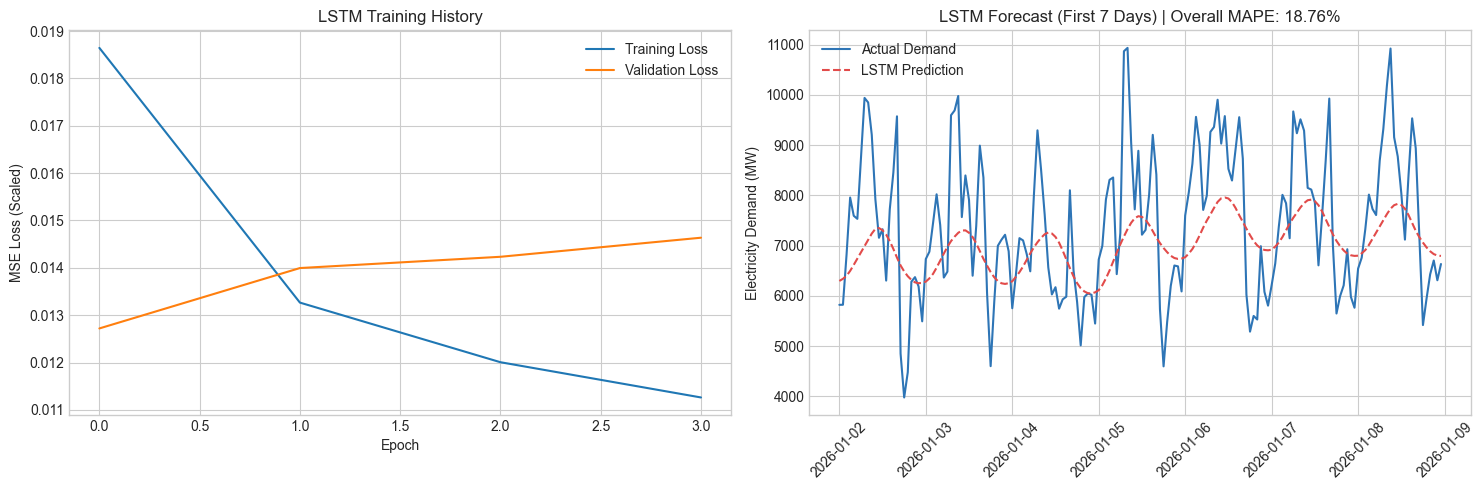

In [30]:
# 7. Visualize LSTM Training Loss & Predictions
plt.figure(figsize=(15, 5))

# Plot 1: Training vs Validation Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training History")
plt.ylabel("MSE Loss (Scaled)")
plt.xlabel("Epoch")
plt.legend()

# Plot 2: Prediction vs Actuals (First Week of 2026 Test Set)
plt.subplot(1, 2, 2)
# Align dates. Test set starts at split_date (0) but sequences eat first 24 hours.
test_dates = test_df['timestamp'].iloc[TIME_STEPS:].values

# Plot just the first 168 hours (7 days) for clear visualization
plot_len = 168 
plt.plot(test_dates[:plot_len], y_test_mw[:plot_len], label='Actual Demand', color='#2E75B6')
plt.plot(test_dates[:plot_len], y_pred_mw[:plot_len], label='LSTM Prediction', color='#E24B4A', linestyle='--')
plt.title(f"LSTM Forecast (First 7 Days) | Overall MAPE: {lstm_mape:.2f}%")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 10. Final Model Comparison
Now that we have trained all three architectures (XGBoost, Prophet, and LSTM), let's compare their performance side-by-side using RMSE and MAPE to officially declare the winning model for deployment.

=== Final Model Evaluation Metrics ===


,Model,RMSE (MW),MAPE (%)
0,XGBoost (Walk-Forward),790.585222,6.910739
1,XGBoost (Baseline),823.737468,7.183883
2,LSTM,2195.089448,18.762074
3,Prophet,4927.042322,47.086724


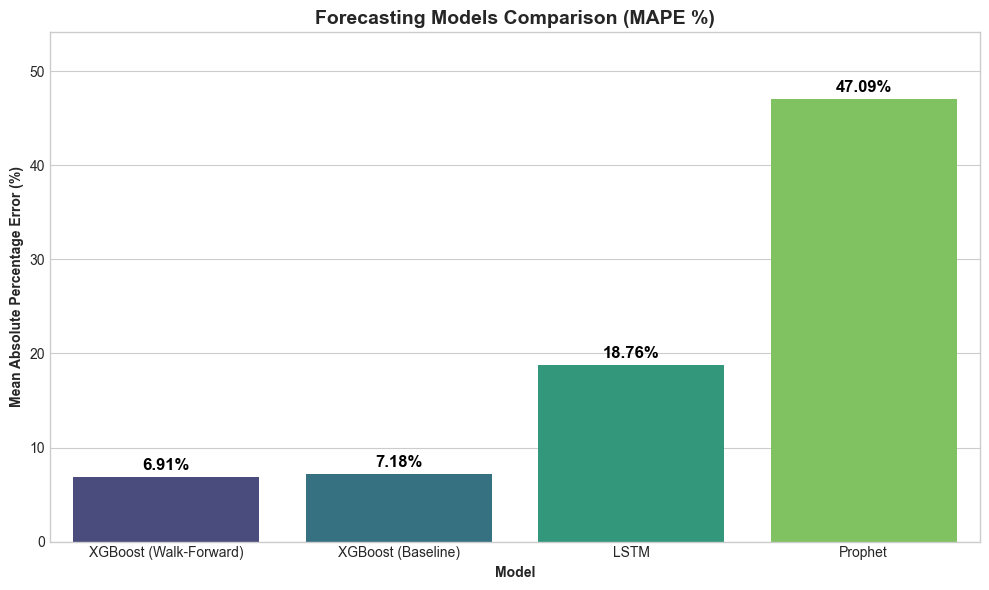

🏆 The Winning Model is: XGBoost (Walk-Forward) with 6.91% MAPE


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Compile Metrics into a DataFrame
comparison_data = {
    'Model': ['XGBoost (Baseline)', 'XGBoost (Walk-Forward)', 'Prophet', 'LSTM'],
    'RMSE (MW)': [rmse, wf_rmse, p_rmse, lstm_rmse],
    'MAPE (%)': [mape, wf_mape, p_mape, lstm_mape]
}

comparison_df = pd.DataFrame(comparison_data)
# Sort by MAPE (lower is better)
comparison_df = comparison_df.sort_values(by='MAPE (%)').reset_index(drop=True)

print("=== Final Model Evaluation Metrics ===")
display(comparison_df)

# 2. Visualize the Comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='MAPE (%)', data=comparison_df, palette='viridis')

# Add MAPE labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.title('Forecasting Models Comparison (MAPE %)', fontweight='bold', fontsize=14)
plt.ylabel('Mean Absolute Percentage Error (%)', fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylim(0, comparison_df['MAPE (%)'].max() * 1.15) # Give some headroom
plt.tight_layout()
plt.show()

winning_model_name = comparison_df.iloc[0]['Model']
print(f"🏆 The Winning Model is: {winning_model_name} with {comparison_df.iloc[0]['MAPE (%)']:.2f}% MAPE")